In [48]:
from pathlib import Path
import sys
import time
import statistics
import platform

import torch
import pandas as pd
import matplotlib.pyplot as plt


cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)
print("PyTorch:", torch.__version__)
print("System:", platform.platform())

Project root: /Users/salmannasyrov/PycharmProjects/ai360-recsys-2026
PyTorch: 2.14.1
System: macOS-15.5-arm64-arm-64bit-Mach-O


In [49]:
from src.data import load_prepared
from src.polynomial import FactorizedPolynomialRegression

In [50]:
data = load_prepared(
    "data/processed/movielens1m"
)

print("Train rows:", len(data.train))
print("Validation rows:", len(data.validation))
print("Test rows:", len(data.test))

print()
print("Users:", data.n_users)
print("Items:", data.n_items)

n_features = (
    data.n_users
    + data.n_items
)

print("Total one-hot features:", n_features)

Train rows: 700146
Validation rows: 150002
Test rows: 149990

Users: 6040
Items: 3652
Total one-hot features: 9692


In [51]:
data.train.head()

,row_id,user_id,item_id,rating,timestamp,user_idx,item_idx,known_user,known_item
0,0,1,1193,5,978300760,0,1079,True,True
1,1,1,661,3,978302109,0,632,True,True
2,2,1,914,3,978301968,0,831,True,True
3,3,1,3408,4,978300275,0,3129,True,True
4,5,1,1197,3,978302268,0,1082,True,True


In [52]:
def make_one_hot_features(
    frame,
    n_users,
    n_items,
):
    n_samples = len(frame)

    n_features = (
        n_users
        + n_items
    )

    x = torch.zeros(
        n_samples,
        n_features,
        dtype=torch.float32,
    )

    rows = torch.arange(
        n_samples
    )

    user_idx = torch.tensor(
        frame["user_idx"].to_numpy(),
        dtype=torch.long,
    )

    item_idx = torch.tensor(
        frame["item_idx"].to_numpy(),
        dtype=torch.long,
    )

    # User features:
    # [0, n_users)
    x[
        rows,
        user_idx,
    ] = 1.0

    # Item features:
    # [n_users, n_users + n_items)
    x[
        rows,
        n_users + item_idx,
    ] = 1.0

    ratings = torch.tensor(
        frame["rating"].to_numpy(),
        dtype=torch.float32,
    )

    return x, ratings

In [53]:
x_train, y_train = make_one_hot_features(
    data.train,
    data.n_users,
    data.n_items,
)

print("X shape:", x_train.shape)
print("y shape:", y_train.shape)

print()
print("First rating:", y_train[0].item())

print(
    "Active features in first sample:",
    torch.nonzero(
        x_train[0]
    ).flatten().tolist(),
)

X shape: torch.Size([700146, 9692])
y shape: torch.Size([700146])

First rating: 5.0
Active features in first sample: [0, 7119]


In [54]:
active_features = (
    x_train.sum(dim=1)
)

print(
    "All samples have exactly two active features:",
    torch.all(
        active_features == 2
    ).item(),
)

print(
    "First 10 feature counts:",
    active_features[:10],
)

All samples have exactly two active features: True
First 10 feature counts: tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])


In [55]:
torch.manual_seed(42)

n_factors = 16

model = FactorizedPolynomialRegression(
    n_features=n_features,
    n_factors=n_factors,
)

print(model)

FactorizedPolynomialRegression()


In [56]:
batch_size = 8

x_batch = x_train[
    :batch_size
]

user_idx = torch.tensor(
    data.train.iloc[
        :batch_size
    ]["user_idx"].to_numpy(),
    dtype=torch.long,
)

item_idx = torch.tensor(
    data.train.iloc[
        :batch_size
    ]["item_idx"].to_numpy(),
    dtype=torch.long,
)

rating_batch = y_train[
    :batch_size
]

print("Batch shape:", x_batch.shape)

print("Users:")
print(user_idx)

print()

print("Items:")
print(item_idx)

print()

print("Ratings:")
print(rating_batch)

Batch shape: torch.Size([8, 9692])
Users:
tensor([0, 0, 0, 0, 0, 0, 0, 0])

Items:
tensor([1079,  632,  831, 3129, 1082, 1170, 2560,  577])

Ratings:
tensor([5., 3., 3., 4., 3., 5., 5., 4.])


In [57]:
with torch.no_grad():
    direct = model.interaction_direct(
        x_batch
    )

print(direct)

tensor([ 2.0659e-04, -6.1624e-04, -5.6902e-04,  4.7004e-04,  8.3259e-04,
        -9.9593e-05,  9.1023e-04,  7.5488e-04])


In [58]:
with torch.no_grad():
    fast = model.interaction_fast(
        x_batch
    )

print(fast)

tensor([ 2.0659e-04, -6.1624e-04, -5.6902e-04,  4.7004e-04,  8.3259e-04,
        -9.9593e-05,  9.1023e-04,  7.5488e-04])


In [59]:
with torch.no_grad():
    sparse_direct = (
        model.factors[
            user_idx
        ]
        *
        model.factors[
            data.n_users
            + item_idx
        ]
    ).sum(dim=1)

print(sparse_direct)

tensor([ 2.0659e-04, -6.1624e-04, -5.6902e-04,  4.7004e-04,  8.3259e-04,
        -9.9593e-05,  9.1023e-04,  7.5488e-04])


In [60]:
direct_fast_difference = (
    direct - fast
).abs()

direct_sparse_difference = (
    direct - sparse_direct
).abs()

print(
    "Max direct-fast difference:",
    direct_fast_difference.max().item(),
)

print(
    "Max direct-sparse difference:",
    direct_sparse_difference.max().item(),
)

print()

print(
    "Direct ≈ Fast:",
    torch.allclose(
        direct,
        fast,
        rtol=1e-5,
        atol=1e-5,
    ),
)

print(
    "Direct ≈ Sparse:",
    torch.allclose(
        direct,
        sparse_direct,
        rtol=1e-5,
        atol=1e-5,
    ),
)

Max direct-fast difference: 1.1641532182693481e-10
Max direct-sparse difference: 0.0

Direct ≈ Fast: True
Direct ≈ Sparse: True


In [61]:
def measure_time(
    function,
    repeats=20,
    warmup=3,
):
    measurements = []

    with torch.no_grad():
        for _ in range(warmup):
            function()

        for _ in range(repeats):
            start = time.perf_counter()

            function()

            end = time.perf_counter()

            measurements.append(
                end - start
            )

    return statistics.median(
        measurements
    )

In [62]:
direct_time = measure_time(
    lambda: model.interaction_direct(
        x_batch
    )
)

fast_time = measure_time(
    lambda: model.interaction_fast(
        x_batch
    )
)

sparse_time = measure_time(
    lambda: (
        model.factors[
            user_idx
        ]
        *
        model.factors[
            data.n_users
            + item_idx
        ]
    ).sum(dim=1)
)

print(
    f"Generic direct: "
    f"{direct_time * 1000:.4f} ms"
)

print(
    f"Fast FM:        "
    f"{fast_time * 1000:.4f} ms"
)

print(
    f"Sparse direct:  "
    f"{sparse_time * 1000:.4f} ms"
)

Generic direct: 2100.8137 ms
Fast FM:        0.1208 ms
Sparse direct:  0.0054 ms


In [63]:
fast_speedup = (
    direct_time
    / fast_time
)

sparse_speedup = (
    direct_time
    / sparse_time
)

print(
    f"Fast FM speedup over generic direct: "
    f"{fast_speedup:.2f}x"
)

print(
    f"Sparse MovieLens speedup over generic direct: "
    f"{sparse_speedup:.2f}x"
)

Fast FM speedup over generic direct: 17388.97x
Sparse MovieLens speedup over generic direct: 390849.00x


In [64]:
runtime_df = pd.DataFrame({
    "method": [
        "Generic direct",
        "Fast FM",
        "Sparse user-item",
    ],
    "runtime_ms": [
        direct_time * 1000,
        fast_time * 1000,
        sparse_time * 1000,
    ],
})

runtime_df

,method,runtime_ms
0,Generic direct,2100.813708
1,Fast FM,0.120813
2,Sparse user-item,0.005375


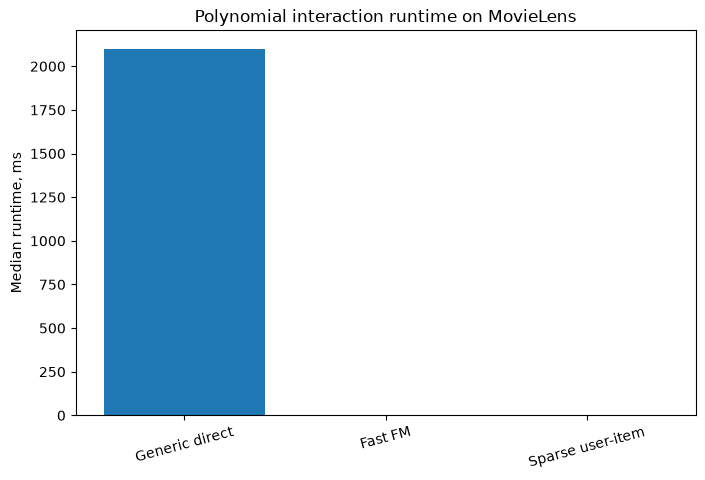

In [65]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    runtime_df["method"],
    runtime_df["runtime_ms"],
)

plt.ylabel(
    "Median runtime, ms"
)

plt.title(
    "Polynomial interaction runtime on MovieLens"
)

plt.xticks(
    rotation=15
)

plt.show()

In [66]:
n_users = data.n_users
n_items = data.n_items

n_features = (
    n_users
    + n_items
)

all_polynomial_pairs = (
    n_features
    * (n_features - 1)
    // 2
)

possible_user_item_pairs = (
    n_users
    * n_items
)

factorized_parameters = (
    n_features
    * n_factors
)

print(
    "All generic polynomial pairs:",
    all_polynomial_pairs,
)

print(
    "Possible user-item pairs:",
    possible_user_item_pairs,
)

print(
    "Factorized interaction parameters:",
    factorized_parameters,
)

All generic polynomial pairs: 46962586
Possible user-item pairs: 22058080
Factorized interaction parameters: 155072


In [67]:
generic_compression = (
    all_polynomial_pairs
    / factorized_parameters
)

user_item_compression = (
    possible_user_item_pairs
    / factorized_parameters
)

print(
    f"Generic polynomial / factorized: "
    f"{generic_compression:.2f}x"
)

print(
    f"User-item interactions / factorized: "
    f"{user_item_compression:.2f}x"
)

Generic polynomial / factorized: 302.84x
User-item interactions / factorized: 142.24x


In [68]:
parameter_df = pd.DataFrame({
    "representation": [
        "Generic second-order polynomial",
        "Explicit user-item interactions",
        "Factorized representation",
    ],
    "interaction_parameters": [
        all_polynomial_pairs,
        possible_user_item_pairs,
        factorized_parameters,
    ],
})

parameter_df

,representation,interaction_parameters
0,Generic second-order polynomial,46962586
1,Explicit user-item interactions,22058080
2,Factorized representation,155072


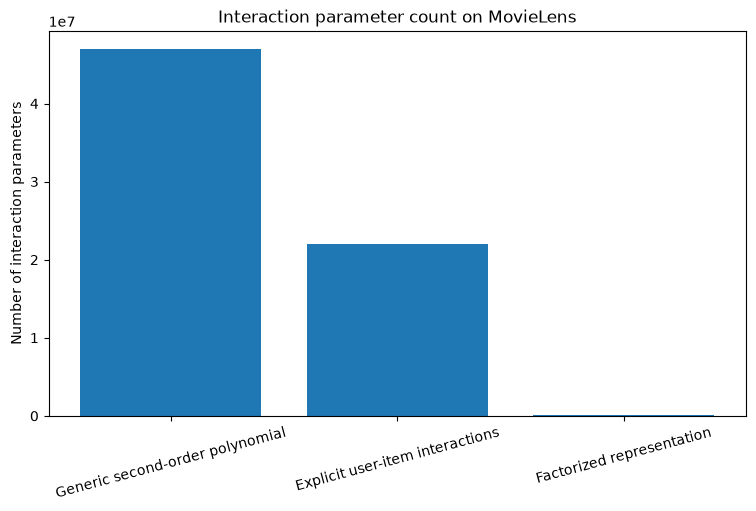

In [69]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    parameter_df["representation"],
    parameter_df[
        "interaction_parameters"
    ],
)

plt.ylabel(
    "Number of interaction parameters"
)

plt.title(
    "Interaction parameter count on MovieLens"
)

plt.xticks(
    rotation=15
)

plt.show()

In [90]:
import importlib
import src.polynomial

print("Loaded from:", src.polynomial.__file__)

importlib.reload(src.polynomial)

print(
    "UserItemPolynomialRegression2:",
    hasattr(
        src.polynomial,
        "UserItemPolynomialRegression2",
    ),
)

print(
    "UserItemFactorizedPolynomialRegression:",
    hasattr(
        src.polynomial,
        "UserItemFactorizedPolynomialRegression",
    ),
)

Loaded from: /Users/salmannasyrov/PycharmProjects/ai360-recsys-2026/src/polynomial.py
UserItemPolynomialRegression2: True
UserItemFactorizedPolynomialRegression: True


In [91]:
from src.models import (
    TrainingConfig,
    fit_model,
)

from src.polynomial import (
    UserItemPolynomialRegression2,
    UserItemFactorizedPolynomialRegression,
)

print("Training imports OK")

Training imports OK


In [92]:
def make_rating_tensors(frame):
    user_idx = torch.tensor(
        frame["user_idx"].to_numpy(),
        dtype=torch.long,
    )

    item_idx = torch.tensor(
        frame["item_idx"].to_numpy(),
        dtype=torch.long,
    )

    ratings = torch.tensor(
        frame["rating"].to_numpy(),
        dtype=torch.float32,
    )

    return user_idx, item_idx, ratings


train_users, train_items, train_ratings = make_rating_tensors(
    data.train
)

val_users, val_items, val_ratings = make_rating_tensors(
    data.validation
)

print("Train users:", train_users.shape)
print("Train items:", train_items.shape)
print("Train ratings:", train_ratings.shape)

print()

print("Validation users:", val_users.shape)
print("Validation items:", val_items.shape)
print("Validation ratings:", val_ratings.shape)

Train users: torch.Size([700146])
Train items: torch.Size([700146])
Train ratings: torch.Size([700146])

Validation users: torch.Size([150002])
Validation items: torch.Size([150002])
Validation ratings: torch.Size([150002])


In [93]:
training_config = TrainingConfig(
    epochs=200,
    batch_size=1024,
    learning_rate=0.01,
    optimizer="adam",
    reg_bias=0.01,
    reg_factors=0.05,
    patience=20,
    min_delta=0.0,
    seed=42,
)

training_config

TrainingConfig(epochs=200, batch_size=1024, learning_rate=0.01, optimizer='adam', reg_bias=0.01, reg_factors=0.05, patience=20, min_delta=0.0, seed=42)

In [94]:
poly_check = UserItemPolynomialRegression2(
    n_users=data.n_users,
    n_items=data.n_items,
)

factor_check = UserItemFactorizedPolynomialRegression(
    n_users=data.n_users,
    n_items=data.n_items,
    n_factors=16,
)

sample_users = train_users[:8]
sample_items = train_items[:8]

poly_prediction = poly_check(
    sample_users,
    sample_items,
)

factor_prediction = factor_check(
    sample_users,
    sample_items,
)

print("Polynomial prediction shape:", poly_prediction.shape)
print("Factorized prediction shape:", factor_prediction.shape)

print()

print(
    "Polynomial bias L2:",
    poly_check.bias_l2().item(),
)

print(
    "Polynomial interaction L2:",
    poly_check.factor_l2().item(),
)

print(
    "Factorized bias L2:",
    factor_check.bias_l2().item(),
)

print(
    "Factorized interaction L2:",
    factor_check.factor_l2().item(),
)

Polynomial prediction shape: torch.Size([8])
Factorized prediction shape: torch.Size([8])

Polynomial bias L2: 0.0
Polynomial interaction L2: 0.0
Factorized bias L2: 0.0
Factorized interaction L2: 15.474223136901855


In [99]:
polynomial_model = UserItemPolynomialRegression2(
    n_users=data.n_users,
    n_items=data.n_items,
)

polynomial_result = fit_model(
    polynomial_model,
    train_users,
    train_items,
    train_ratings,
    val_user_idx=val_users,
    val_item_idx=val_items,
    val_rating=val_ratings,
    config=training_config,
)

print("Polynomial training finished")
print("Best epoch:", polynomial_result.best_epoch)
print(
    "Fit time:",
    polynomial_result.fit_time_seconds,
)

Polynomial training finished
Best epoch: 40
Fit time: 5898.553566582996


In [100]:
polynomial_history = pd.DataFrame(
    polynomial_result.history
)

polynomial_history

,epoch,train_loss,train_mse,train_loss_with_regularization,train_rmse,val_rmse
0,1.0,0.626740,0.625386,0.626740,0.790814,0.913945
1,2.0,0.437290,0.432649,0.437290,0.657761,0.911665
2,3.0,0.306352,0.297109,0.306352,0.545077,0.911498
3,4.0,0.215077,0.200785,0.215077,0.448091,0.912380
4,5.0,0.154317,0.135015,0.154317,0.367444,0.913641
5,6.0,0.113689,0.089733,0.113689,0.299554,0.915413
6,7.0,0.088094,0.060031,0.088094,0.245012,0.916522
7,8.0,0.072407,0.040900,0.072407,0.202237,0.917220
8,9.0,0.062870,0.028633,0.062870,0.169213,0.919158
9,10.0,0.058004,0.021725,0.058004,0.147394,0.919570


In [101]:
polynomial_best = (
    polynomial_history[
        polynomial_history["epoch"]
        == float(polynomial_result.best_epoch)
    ]
    .iloc[0]
)

print("Polynomial Regression")
print(
    "Best epoch:",
    polynomial_result.best_epoch,
)
print(
    "Train RMSE:",
    polynomial_best["train_rmse"],
)
print(
    "Validation RMSE:",
    polynomial_best["val_rmse"],
)
print(
    "Training time:",
    polynomial_result.fit_time_seconds,
)

Polynomial Regression
Best epoch: 40
Train RMSE: 0.11837651580572128
Validation RMSE: 0.9099603891372681
Training time: 5898.553566582996


In [96]:
factorized_model = UserItemFactorizedPolynomialRegression(
    n_users=data.n_users,
    n_items=data.n_items,
    n_factors=16,
)

factorized_result = fit_model(
    factorized_model,
    train_users,
    train_items,
    train_ratings,
    val_user_idx=val_users,
    val_item_idx=val_items,
    val_rating=val_ratings,
    config=training_config,
)

print("Factorized training finished")
print(
    "Best epoch:",
    factorized_result.best_epoch,
)
print(
    "Fit time:",
    factorized_result.fit_time_seconds,
)

Factorized training finished
Best epoch: 1
Fit time: 9.174395374997403


In [97]:
factorized_history = pd.DataFrame(
    factorized_result.history
)

factorized_history

,epoch,train_loss,train_mse,train_loss_with_regularization,train_rmse,val_rmse
0,1.0,0.682207,0.681449,0.682207,0.825499,0.888947
1,2.0,0.593930,0.592646,0.593930,0.769835,0.892699
2,3.0,0.558344,0.556710,0.558344,0.746130,0.902061
3,4.0,0.542153,0.540269,0.542153,0.735030,0.909776
4,5.0,0.534001,0.531921,0.534001,0.729329,0.915915
5,6.0,0.527955,0.525700,0.527955,0.725052,0.921992
6,7.0,0.524104,0.521715,0.524104,0.722298,0.927044
7,8.0,0.521672,0.519171,0.521672,0.720535,0.930914
8,9.0,0.519397,0.516795,0.519397,0.718885,0.932911
9,10.0,0.518115,0.515431,0.518115,0.717936,0.937117


In [102]:
factorized_best = (
    factorized_history[
        factorized_history["epoch"]
        == float(factorized_result.best_epoch)
    ]
    .iloc[0]
)

print("Factorized Polynomial Regression")
print(
    "Best epoch:",
    factorized_result.best_epoch,
)
print(
    "Train RMSE:",
    factorized_best["train_rmse"],
)
print(
    "Validation RMSE:",
    factorized_best["val_rmse"],
)
print(
    "Training time:",
    factorized_result.fit_time_seconds,
)

Factorized Polynomial Regression
Best epoch: 1
Train RMSE: 0.8254991173744202
Validation RMSE: 0.8889472484588623
Training time: 9.174395374997403


In [103]:
comparison_df = pd.DataFrame({
    "model": [
        "Polynomial Regression",
        "Factorized Polynomial Regression",
    ],
    "best_epoch": [
        polynomial_result.best_epoch,
        factorized_result.best_epoch,
    ],
    "train_rmse": [
        polynomial_best["train_rmse"],
        factorized_best["train_rmse"],
    ],
    "validation_rmse": [
        polynomial_best["val_rmse"],
        factorized_best["val_rmse"],
    ],
    "fit_seconds": [
        polynomial_result.fit_time_seconds,
        factorized_result.fit_time_seconds,
    ],
})

comparison_df

,model,best_epoch,train_rmse,validation_rmse,fit_seconds
0,Polynomial Regression,40,0.118377,0.909960,5898.553567
1,Factorized Polynomial Regression,1,0.825499,0.888947,9.174395


In [104]:
def trainable_parameter_count(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


parameter_comparison = pd.DataFrame({
    "model": [
        "Polynomial Regression",
        "Factorized Polynomial Regression",
    ],
    "parameters": [
        trainable_parameter_count(
            polynomial_model
        ),
        trainable_parameter_count(
            factorized_model
        ),
    ],
})

parameter_comparison

,model,parameters
0,Polynomial Regression,46972279
1,Factorized Polynomial Regression,164765


In [105]:
poly_parameters = trainable_parameter_count(
    polynomial_model
)

factorized_parameters = trainable_parameter_count(
    factorized_model
)

compression = (
    poly_parameters
    / factorized_parameters
)

print(
    "Polynomial parameters:",
    poly_parameters,
)

print(
    "Factorized parameters:",
    factorized_parameters,
)

print(
    f"Parameter reduction: {compression:.2f}x"
)

Polynomial parameters: 46972279
Factorized parameters: 164765
Parameter reduction: 285.09x


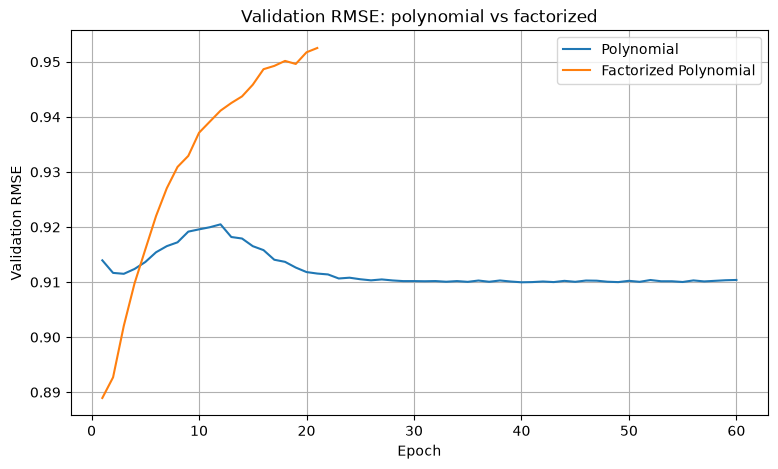

In [106]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    polynomial_history["epoch"],
    polynomial_history["val_rmse"],
    label="Polynomial",
)

plt.plot(
    factorized_history["epoch"],
    factorized_history["val_rmse"],
    label="Factorized Polynomial",
)

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")

plt.title(
    "Validation RMSE: polynomial vs factorized"
)

plt.legend()
plt.grid()

plt.show()

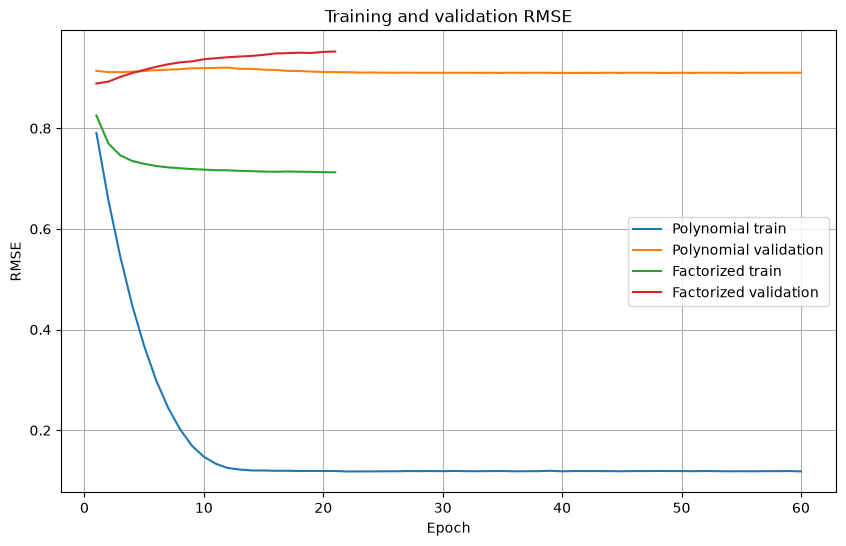

In [107]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    polynomial_history["epoch"],
    polynomial_history["train_rmse"],
    label="Polynomial train",
)

plt.plot(
    polynomial_history["epoch"],
    polynomial_history["val_rmse"],
    label="Polynomial validation",
)

plt.plot(
    factorized_history["epoch"],
    factorized_history["train_rmse"],
    label="Factorized train",
)

plt.plot(
    factorized_history["epoch"],
    factorized_history["val_rmse"],
    label="Factorized validation",
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")

plt.title(
    "Training and validation RMSE"
)

plt.legend()
plt.grid()

plt.show()